# Detecting housing bubbles on the danish housing market

This project is trying to detect if there are any explosive behaviour on the danish housing market, from the first quarter of 1998 to the fourth quarter of 2023. 

The idea of the project is to test the real danish housing prices for unite roots. The procedure used is the BSADF test, wich is introduced in Philips (2011). The BSADF differentiates itself from the Augmented Dickey fuller test By introducing a flexible testing window in a backwards expanding supremum, however the test is conducted in a forward recursive manner.

In [2]:
#importing packages
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

The following code shows that the last collom of the variable has no values, and therefore we want to delete it.

The code first displays the data, in which we can see that row 103 is missing some values. The last part of the code deletes the unwanted row. The new dataset can be seen in the output. 

In [3]:
# Read the Excel file into a DataFrame
df = pd.read_excel("Huspris_kvartal.xlsx")

# Display the original DataFrame
print("Original DataFrame:")
print(df)

# Drop the last row
df = df.drop(df.index[-1])

# Display the modified DataFrame without the last row
print("\nDataFrame after deleting the last row:")
print(df)



Original DataFrame:
     Period  EF_Hele_landet  EF_Region_H  EL_Hele_landet  EL_Region_H  \
0    1998q1           870.0       1290.0           614.0        657.0   
1    1998q2           900.0       1358.0           634.0        676.0   
2    1998q3           869.0       1315.0           626.0        663.0   
3    1998q4           897.0       1400.0           654.0        703.0   
4    1999q1           933.0       1433.0           698.0        765.0   
..      ...             ...          ...             ...          ...   
99   2022q4          2390.0       4555.0          2739.0       3318.0   
100  2023q1          2526.0       4467.0          2754.0       3245.0   
101  2023q2          2621.0       4646.0          2943.0       3469.0   
102  2023q3          2663.0       4724.0          2983.0       3557.0   
103  2023q4             NaN          NaN             NaN          NaN   

        Rente     CPI  Inflation     RHP_EFHL     RHP_EFRH     RHP_ELHL  \
0    6.783077   71.67     0.

In this section we load our data and mark that the data is on a quarterly basis.

In [4]:
file_path = 'Huspris_kvartal.xlsx'
df = pd.read_excel(file_path)

df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

In the next section the code plots the real house prices for single family houses in the region of Copenhagen.

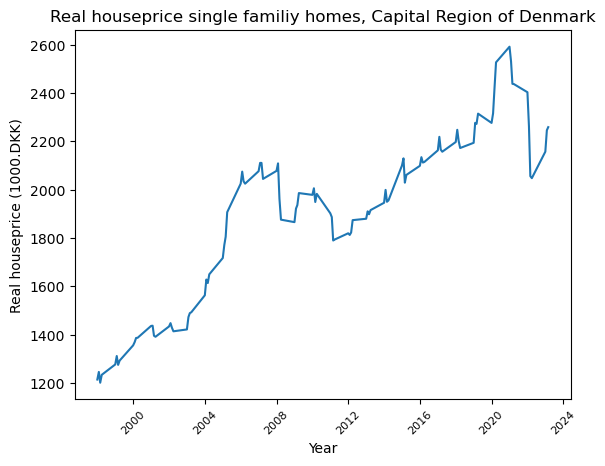

In [35]:
# Plotting the values of the column RHP_EFHL
price = df['RHP_EFHL']
plt.plot(df.index, price)
plt.title('Real houseprice single familiy homes, Capital Region of Denmark') 
plt.xlabel('Year')
plt.ylabel('Real houseprice (1000.DKK)')
plt.xticks(rotation=45)
plt.show()

We observe a sharp increase in house prices from 2005 to 2007, followed by a sharp correction. Likewise, we obersvere sharp increases in house prices in 2021, which diverges from the long run growth developments, once again accompanied by a downturn in prices. We proceed to plot the quarterly growth rates for depper analysis.

/var/folders/sv/y0_gb2yj6zxb__6rrppst5b80000gn/T/ipykernel_96492/365525195.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  growth_rates = df['RHP_EFRH'].pct_change() * 100


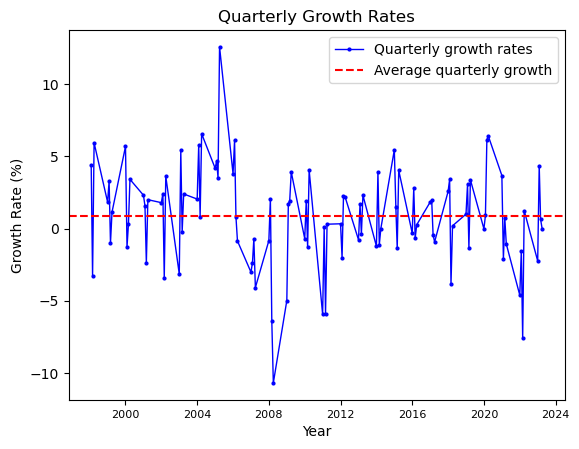

Average quearterly growth rate is: 0.838294975294267


In [33]:
# Calculating quarterly growth rates
growth_rates = df['RHP_EFRH'].pct_change() * 100
average_growth = growth_rates.mean()

# We proceed to plot the growth rates in a histogram
plt.plot(df.index, growth_rates, color='blue', marker='o', linewidth=1, markersize=2, label='Quarterly growth rates')
plt.axhline(average_growth, color='red', linestyle='--', label='Average quarterly growth')
plt.title('Quarterly Growth Rates')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.show()

print('Average quearterly growth rate is:', average_growth)


## Interpretation of our data
Looking at the raw data from Copenhagen, we see an immediate explovsive growth in the house prices in the period of 2005-2007 and again in 2020-2021. Indeed analysing the growth rates we oberserve quarterly growth rates exceeding 10%, consequently followed by quarters with negative growth rates of the magnitude alike. The average quarterly growth rate acroos the entire sample period is 0.838%, which translates to 3.352% on an annual basis.
To formally check wether explsosive evolvong houseprices is in fact present, we will now conduct a BSADF test to check if our time series contains unit roots and thus indicating a bubble might be present. The test is conducted in the algorithm below. 

# BSADF Test for house price bubbles 

DatetimeIndex(['2004-02-01', '2004-03-01', '2004-04-01', '2005-01-01',
               '2005-02-01', '2005-03-01', '2005-04-01', '2006-01-01',
               '2006-02-01', '2006-03-01', '2006-04-01', '2014-03-01',
               '2020-04-01', '2021-01-01', '2021-02-01', '2022-03-01',
               '2022-04-01'],
              dtype='datetime64[ns]', name='Period', freq=None)


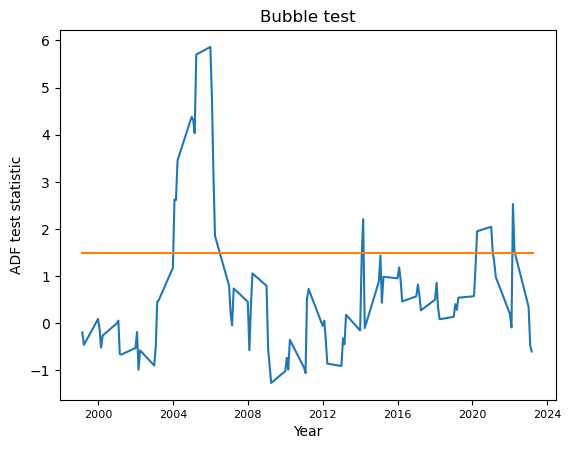

In [6]:
#this is a bubble detecting algorithm developed by Phillips and Yu (2011) and Phillips et al. (2015) 
#it is based on the augmented Dickey-Fuller test and is used to detect bubbles in financial data.

# We generate price the variable
prices = df['RHP_EFRH']

# Inputting the parameters
r0 = int(len(prices) * 0.05)
adf_lags = 1
crit = 1.49
#transforming data
log_prices = np.array(np.log(prices))
delta_log_prices = log_prices[1:] - log_prices[:-1]
n = len(delta_log_prices)
BSADF = np.array([])
#calculating ADF stats
for r2 in range(r0,n):
    ADFS = np.array([])
    for r1 in range(0,r2-r0+1):
        X0 = log_prices[r1:r2+1]
        X = pd.DataFrame()
        X[0] = X0
        for j in range(1,adf_lags+1):
            X[j] = np.append(np.zeros(j),delta_log_prices[r1:r2+1-j])
        X = np.array(X)
        Y = delta_log_prices[r1:r2+1]
        reg = sm.OLS(Y,sm.add_constant(X))
        res = reg.fit()
        ADFS = np.append(ADFS, res.params[1]/res.bse[1])
    BSADF = np.append(BSADF, max(ADFS))
#finally, we visualise the results
plt.rc('xtick',labelsize = 8)
plt.plot(prices.index[r0+1:],BSADF)
plt.plot(prices.index[r0+1:],np.ones(len(BSADF))*crit)
plt.title('Bubble test')
plt.xlabel('Year')
plt.ylabel('ADF test statistic')

#printing dates when bubbles were detected
print(prices.index[r0+1:][BSADF > crit])

## Interpretation of our data and results
Looking at the output the date TimeIndex is where the t-test value is above the 5% critical value, and therefore could be characterized as a housing bubble. We notice that the bubble of the financiel crises of 2008 is marked, also with a build up starting in the period of 2005. A more interesting result is, that there also seems to be a bubble after the outbreak of Covid-19 pandemic. An explination of the rise in house prices (as well as other types of assets) is likely due to households limited consumption options due to lockdown restiction. This in turn, leads to higher demand for assets such as housing or stock, vacations home, etc. However, the results should to be taken with a precaution, as this is only the raw price development and therefore without any fundamentel factors taken into account; such as the interest rate level or the disposabel income. The results might still be viable in giving some indication that a bubble is present. A possible extension would be a construct a fundamental adjusted houseprice and run the BSADF test on this sample. However this is a rather rigourous task, and beyond the scope and purpose of this coding project.